In [ ]:
# ============================================================
# 1. Import Libraries
# ============================================================

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim

# TorchVision for datasets and image transforms
from torchvision import datasets, transforms

# DataLoader helps load data in batches
from torch.utils.data import DataLoader, random_split

# Visualization libraries
import matplotlib.pyplot as plt

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# NumPy
import numpy as np

In [ ]:
# ============================================================
# 2. Device Configuration
# ============================================================

# Use GPU if available for faster training
# Otherwise use CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {device}")

Using device: cuda


In [ ]:

# ============================================================
# 3. Data Preprocessing
# ============================================================

# Transform images before feeding them into the neural network
#
# ToTensor():
# Converts image from PIL format to Tensor
# Also scales pixel values from [0,255] → [0,1]
#
# Normalize():
# Normalizes the data using MNIST mean and standard deviation
# This helps training become faster and more stable

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
# ============================================================
# 4. Load MNIST Dataset
# ============================================================

# Download training dataset
full_train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

# Download test dataset
test_dataset = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [ ]:
# ============================================================
# 5. Split Dataset into Train and Validation
# ============================================================

# We use:
# 80% for training
# 20% for validation

train_size = int(0.8 * len(full_train_dataset))
validation_size = len(full_train_dataset) - train_size

train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [train_size, validation_size]
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(validation_dataset)}")

Training samples: 48000
Validation samples: 12000


In [ ]:
# ============================================================
# 6. Create DataLoaders
# ============================================================

# DataLoader helps:
# - Load data in batches
# - Shuffle training data
# - Make training faster

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [ ]:
# ============================================================
# 7. Build Neural Network Model - Experiment 1
# ============================================================

# MLP = Multi-Layer Perceptron
# This is a simple fully connected neural network

class MLPModel(nn.Module):

    def __init__(self):
        super(MLPModel, self).__init__()

        self.model = nn.Sequential(

            # Input layer:
            # MNIST image size = 28 x 28 = 784 pixels
            nn.Linear(28 * 28, 128),

            # ReLU activation function
            # Adds non-linearity to the network
            nn.ReLU(),

            # Dropout helps reduce overfitting
            nn.Dropout(0.2),

            # Output layer
            # 10 classes for digits 0 → 9
            nn.Linear(128, 10)
        )

    def forward(self, x):

        # Flatten image:
        # (Batch, 1, 28, 28) → (Batch, 784)
        x = x.view(x.size(0), -1)

        return self.model(x)


# Create model
model = MLPModel().to(device)

print(model)

MLPModel(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
# ============================================================
# 8. Loss Function and Optimizer
# ============================================================

# CrossEntropyLoss:
# Best loss function for multi-class classification

criterion = nn.CrossEntropyLoss()

# Adam optimizer:
# Popular optimizer for deep learning
# Updates model weights during training

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)



In [ ]:

# ============================================================
# 9. Training Function
# ============================================================

def train_model(model, train_loader, validation_loader,
                criterion, optimizer, epochs):

    # Store results for plotting later
    train_losses = []
    validation_losses = []
    validation_accuracies = []

    # Loop through epochs
    for epoch in range(epochs):
      # ====================================================
        # Training Phase
        # ====================================================

        model.train()

        running_train_loss = 0.0

        for images, labels in train_loader:

            # Move data to GPU/CPU
            images = images.to(device)
            labels = labels.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            # Add batch loss
            running_train_loss += loss.item()

        # Average training loss
        train_loss = running_train_loss / len(train_loader)

        train_losses.append(train_loss)
         # ====================================================
        # Validation Phase
        # ====================================================

        model.eval()

        running_validation_loss = 0.0

        correct = 0
        total = 0

        # Disable gradient calculations
        with torch.no_grad():

            for images, labels in validation_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)

                # Validation loss
                loss = criterion(outputs, labels)

                running_validation_loss += loss.item()

                # Predicted class
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        # Average validation loss
        validation_loss = running_validation_loss / len(validation_loader)

        validation_losses.append(validation_loss)

        # Accuracy
        accuracy = 100 * correct / total

        validation_accuracies.append(accuracy)

        # Print epoch results
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Validation Loss: {validation_loss:.4f}")
        print(f"Validation Accuracy: {accuracy:.2f}%")
        print("-" * 40)

    return train_losses, validation_losses, validation_accuracies



In [ ]:
# ============================================================
# 10. Train Experiment 1
# ============================================================

EPOCHS = 5

print("Starting Experiment 1...\n")

train_losses_1, validation_losses_1, accuracies_1 = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS
)

Starting Experiment 1...

Epoch [1/5]
Train Loss: 0.3224
Validation Loss: 0.1620
Validation Accuracy: 95.22%
----------------------------------------
Epoch [2/5]
Train Loss: 0.1606
Validation Loss: 0.1256
Validation Accuracy: 96.32%
----------------------------------------
Epoch [3/5]
Train Loss: 0.1227
Validation Loss: 0.0997
Validation Accuracy: 97.03%
----------------------------------------
Epoch [4/5]
Train Loss: 0.1022
Validation Loss: 0.1079
Validation Accuracy: 96.76%
----------------------------------------
Epoch [5/5]
Train Loss: 0.0879
Validation Loss: 0.0857
Validation Accuracy: 97.41%
----------------------------------------


# The neural network shows strong learning behavior:
# - Decreasing training loss indicates effective optimization
# - High validation accuracy (~97%) indicates good generalization
# - Minor fluctuations in validation loss are normal during training

# Overall: The model performs well on MNIST digit classification task

In [ ]:
# ============================================================
# 11. Evaluate Model on Test Dataset
# ============================================================

def evaluate_model(model, test_loader, criterion):

    model.eval()

    total_loss = 0.0

    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            # Get predicted class
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            # Store predictions for metrics
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Final metrics
    average_loss = total_loss / len(test_loader)

    accuracy = 100 * correct / total

    return average_loss, accuracy, all_labels, all_predictions


# Evaluate Experiment 1
test_loss_1, test_accuracy_1, labels_1, predictions_1 = evaluate_model(
    model,
    test_loader,
    criterion
)

print(f"\nExperiment 1 Test Accuracy: {test_accuracy_1:.2f}%")
print(f"Experiment 1 Test Loss: {test_loss_1:.4f}")


Experiment 1 Test Accuracy: 97.69%
Experiment 1 Test Loss: 0.0777



#  Experiment 1 Final Evaluation


# The model demonstrates strong generalization ability:
# - High test accuracy (97.69%) indicates excellent digit recognition performance
# - Very low test loss (0.0777) confirms stable and confident predictions

# Overall result: The model is highly effective for MNIST classification task

In [ ]:

# ============================================================
# 12. Confusion Matrix and Classification Report
# ============================================================

# Confusion Matrix
cm = confusion_matrix(labels_1, predictions_1)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
report = classification_report(labels_1, predictions_1)

print("\nClassification Report:")
print(report)


Confusion Matrix:
[[ 973    0    1    2    0    1    1    1    1    0]
 [   0 1124    3    2    0    0    1    1    4    0]
 [   2    0 1017    0    0    0    2    4    7    0]
 [   0    0    7  977    0   11    0   10    4    1]
 [   1    0    3    0  948    0    6    4    2   18]
 [   2    0    0    5    3  869    4    1    5    3]
 [   5    3    1    1    3    3  939    0    3    0]
 [   2    2   12    1    0    0    0 1004    0    7]
 [   4    1    7    4    3    3    3    5  943    1]
 [   3    4    2    5    4    2    0    7    7  975]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.98      0.97      0.97      1010
           4       0.99      0.97      0.98       982
           5       0.98      0.97      0.98       892
           6       0.98      0.98      0.98    


#  Model Evaluation Summary


# The confusion matrix shows that most predictions are on the diagonal,
# meaning the model correctly classifies most digits.

# The classification report shows:
# - Precision ~0.98 → predictions are mostly correct
# - Recall ~0.98 → model detects most real digits
# - F1-score ~0.98 → balanced and strong performance

# Final conclusion:
# The model achieves ~98% accuracy on MNIST test data,
# which indicates excellent learning and generalization ability

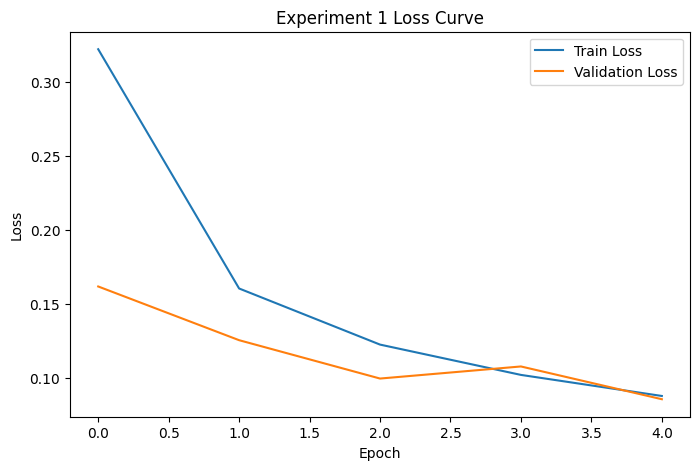

In [ ]:
# ============================================================
# 13. Plot Loss Curves - Experiment 1
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(train_losses_1, label='Train Loss')
plt.plot(validation_losses_1, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Experiment 1 Loss Curve")

plt.legend()

plt.show()

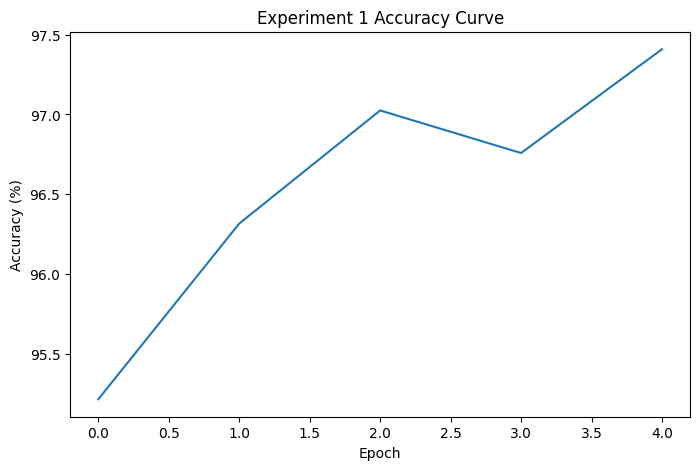

In [ ]:

# ============================================================
# 14. Plot Accuracy Curve - Experiment 1
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(accuracies_1)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Experiment 1 Accuracy Curve")

plt.show()

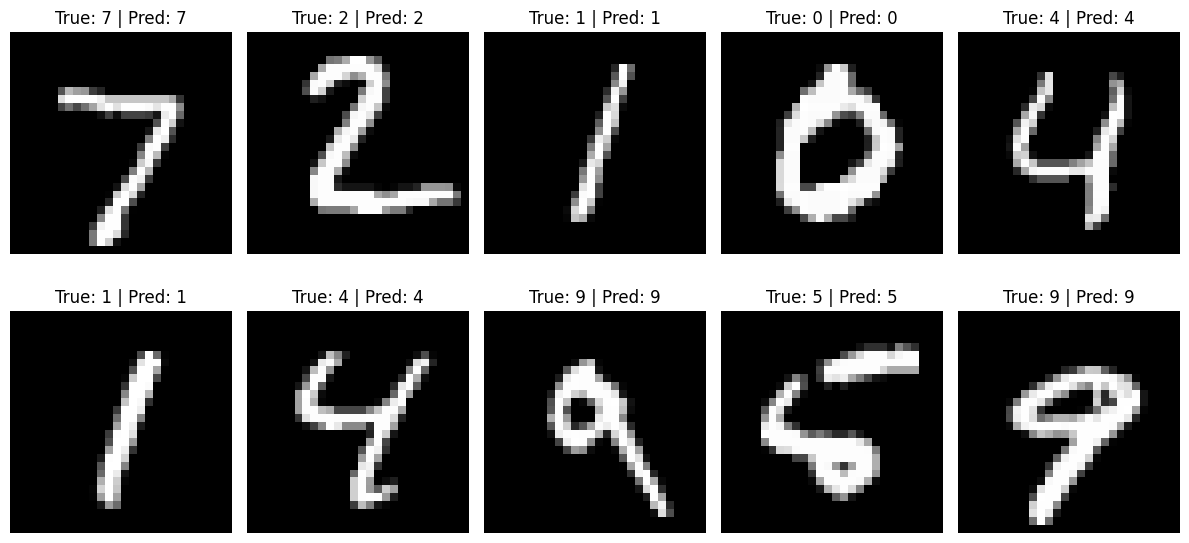

In [ ]:
# ============================================================
# 15. Visualize Predictions
# ============================================================

# Get one batch from test data
images, labels = next(iter(test_loader))

# Move images to device
images_device = images.to(device)

# Predict
model.eval()

with torch.no_grad():

    outputs = model(images_device)

    _, predictions = torch.max(outputs, 1)

# Move predictions back to CPU
predictions = predictions.cpu()

# Plot images
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap='gray')

    plt.title(
        f"True: {labels[i]} | Pred: {predictions[i].item()}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 16. Experiment 2 - Different Architecture
# ============================================================

print("\nStarting Experiment 2...\n")

# Changes:
# - More neurons (256 instead of 128)
# - Tanh activation instead of ReLU
# - Higher learning rate

class MLPModel2(nn.Module):

    def __init__(self):
        super(MLPModel2, self).__init__()

        self.model = nn.Sequential(

            # Larger hidden layer
            nn.Linear(28 * 28, 256),

            # Tanh activation function
            nn.Tanh(),

            # Dropout
            nn.Dropout(0.2),

            # Output layer
            nn.Linear(256, 10)
        )

    def forward(self, x):

        # Flatten image
        x = x.view(x.size(0), -1)

        return self.model(x)


# Create second model
model2 = MLPModel2().to(device)

# Loss function
criterion2 = nn.CrossEntropyLoss()

# Optimizer
optimizer2 = optim.Adam(
    model2.parameters(),
    lr=0.01
)


Starting Experiment 2...



In [ ]:


# ============================================================
# 17. Train Experiment 2
# ============================================================

train_losses_2, validation_losses_2, accuracies_2 = train_model(
    model=model2,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion2,
    optimizer=optimizer2,
    epochs=EPOCHS
)


Epoch [1/5]
Train Loss: 0.4800
Validation Loss: 0.3323
Validation Accuracy: 90.09%
----------------------------------------
Epoch [2/5]
Train Loss: 0.4466
Validation Loss: 0.2986
Validation Accuracy: 91.08%
----------------------------------------
Epoch [3/5]
Train Loss: 0.4105
Validation Loss: 0.2857
Validation Accuracy: 91.71%
----------------------------------------
Epoch [4/5]
Train Loss: 0.3946
Validation Loss: 0.2717
Validation Accuracy: 92.28%
----------------------------------------
Epoch [5/5]
Train Loss: 0.3932
Validation Loss: 0.2490
Validation Accuracy: 93.22%
----------------------------------------


In [ ]:
# ============================================================
# 18. Evaluate Experiment 2
# ============================================================

test_loss_2, test_accuracy_2, labels_2, predictions_2 = evaluate_model(
    model2,
    test_loader,
    criterion2
)

print(f"\nExperiment 2 Test Accuracy: {test_accuracy_2:.2f}%")
print(f"Experiment 2 Test Loss: {test_loss_2:.4f}")


Experiment 2 Test Accuracy: 93.10%
Experiment 2 Test Loss: 0.2401


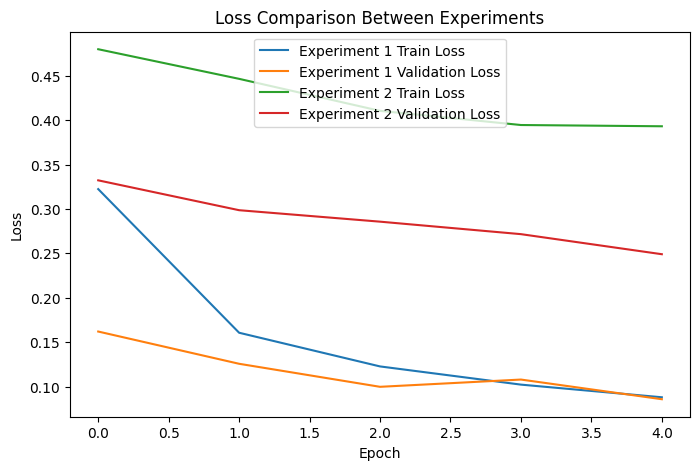

In [ ]:

# ============================================================
# 19. Compare Loss Curves
# ============================================================

plt.figure(figsize=(8,5))

# Experiment 1
plt.plot(
    train_losses_1,
    label='Experiment 1 Train Loss'
)

plt.plot(
    validation_losses_1,
    label='Experiment 1 Validation Loss'
)

# Experiment 2
plt.plot(
    train_losses_2,
    label='Experiment 2 Train Loss'
)

plt.plot(
    validation_losses_2,
    label='Experiment 2 Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Comparison Between Experiments")

plt.legend()

plt.show()

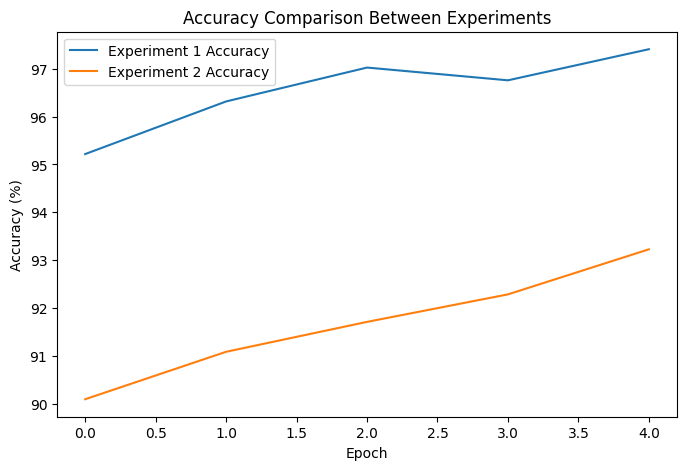

In [ ]:
# ============================================================
# 20. Compare Accuracy Curves
# ============================================================

plt.figure(figsize=(8,5))

# Experiment 1
plt.plot(
    accuracies_1,
    label='Experiment 1 Accuracy'
)

# Experiment 2
plt.plot(
    accuracies_2,
    label='Experiment 2 Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Accuracy Comparison Between Experiments")

plt.legend()

plt.show()


In [ ]:

# ============================================================
# 21. Final Comparison Summary
# ============================================================

print("\n========== FINAL RESULTS ==========")

print(f"Experiment 1 Accuracy: {test_accuracy_1:.2f}%")
print(f"Experiment 2 Accuracy: {test_accuracy_2:.2f}%")

print("===================================")


========== FINAL RESULTS ==========
Experiment 1 Accuracy: 97.69%
Experiment 2 Accuracy: 93.10%


In [ ]:
# ============================================================
# 21. Final Comparison Summary
# ============================================================

print("\n========== FINAL RESULTS ==========")

print(f"Experiment 1 Accuracy: {test_accuracy_1:.2f}%")
print(f"Experiment 2 Accuracy: {test_accuracy_2:.2f}%")

print("===================================")


========== FINAL RESULTS ==========
Experiment 1 Accuracy: 97.69%
Experiment 2 Accuracy: 93.10%
